---
## Section 0 — Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# ── Load ─────────────────────────────────────────────────────────
df = pd.read_csv('cmi_module1_clean-1.csv')
print(f"Dataset shape: {df.shape}")

# ── Class distribution ───────────────────────────────────────────
print("\nsii class distribution:")
dist = df['sii'].value_counts().sort_index()
for cls, cnt in dist.items():
    print(f"  sii={int(cls)}: {cnt} ({cnt/len(df)*100:.1f}%)")

Dataset shape: (8417, 32)

sii class distribution:
  sii=0: 5807 (69.0%)
  sii=1: 1577 (18.7%)
  sii=2: 947 (11.3%)
  sii=3: 86 (1.0%)


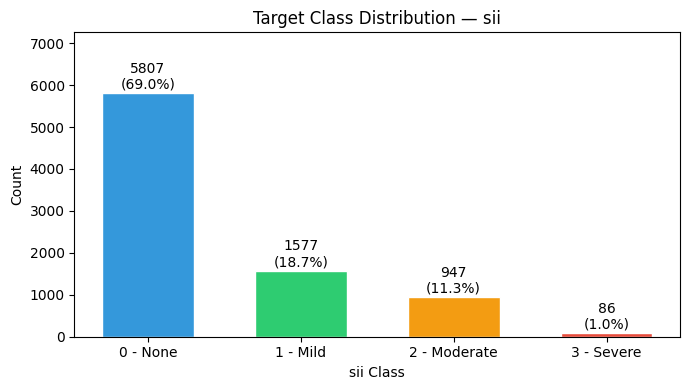

Imbalance ratio: 67.5x (majority/minority)


In [2]:
# ── Class distribution bar chart ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#3498DB','#2ECC71','#F39C12','#E74C3C']
bars = ax.bar(
    ['0 - None','1 - Mild','2 - Moderate','3 - Severe'],
    dist.values, color=colors, edgecolor='white', width=0.6
)
for bar, cnt in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{cnt}\n({cnt/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_xlabel('sii Class')
ax.set_ylabel('Count')
ax.set_title('Target Class Distribution — sii')
ax.set_ylim(0, dist.max() * 1.25)
plt.tight_layout()
plt.savefig('svm_class_distribution.png', dpi=150)
plt.show()
print(f"Imbalance ratio: {dist.max()/dist.min():.1f}x (majority/minority)")

---
## Section 1 — Feature Preparation & Train/Test Split

In [3]:
# ── Define features ──────────────────────────────────────────────
# Exclude target and categorical columns
exclude_cols = ['sii', 'ScreenTime_Category']
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols]
y = df['sii'].astype(int)

CLASSES     = [0, 1, 2, 3]
CLASS_NAMES = ['None', 'Mild', 'Moderate', 'Severe']

print(f"Features used: {len(feature_cols)}")
print(feature_cols)
print(f"\nTarget classes: {sorted(y.unique())}")

Features used: 30
['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-BMI', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Max_Stage', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_FFM', 'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday', 'FGC_Flexibility_Avg', 'FGC_Grip_Avg', 'PAQ_Total', 'SDS_measured', 'BIA_measured', 'FGC_Muscular_Endurance', 'Social_Digital_Displacement', 'Lifestyle_Risk_Score', 'Metabolic_Alarms_Count', 'ScreenTime_Age_Ratio']

Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


In [4]:
# ── 80/20 stratified split ───────────────────────────────────────
# Same split as all team notebooks: random_state=42, stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("\nTrain class distribution:")
for cls, cnt in y_train.value_counts().sort_index().items():
    print(f"  sii={cls}: {cnt} ({cnt/len(y_train)*100:.1f}%)")
print("\nTest class distribution:")
for cls, cnt in y_test.value_counts().sort_index().items():
    print(f"  sii={cls}: {cnt} ({cnt/len(y_test)*100:.1f}%)")

Train: 6733 rows | Test: 1684 rows

Train class distribution:
  sii=0: 4645 (69.0%)
  sii=1: 1261 (18.7%)
  sii=2: 758 (11.3%)
  sii=3: 69 (1.0%)

Test class distribution:
  sii=0: 1162 (69.0%)
  sii=1: 316 (18.8%)
  sii=2: 189 (11.2%)
  sii=3: 17 (1.0%)


In [5]:
# ── StandardScaler ───────────────────────────────────────────────
# SVM is purely distance-based — scaling is CRITICAL
# Features with large ranges (e.g. Weight 12-298) would dominate
# without scaling, making kernel distances meaningless
# Fit on training set ONLY to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("StandardScaler applied — fit on training set only")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

StandardScaler applied — fit on training set only
X_train_scaled: (6733, 30)
X_test_scaled:  (1684, 30)


---
## Section 2 — Hyperparameter Tuning

**Parameters tuned:**
- `kernel` — `linear`: finds a flat hyperplane separating classes; `rbf`: uses Gaussian kernel to map features into higher-dimensional space where nonlinear boundaries become linear.
- `C` — regularisation. Small C = wide margin, more misclassifications allowed. Large C = narrow margin, fewer misclassifications but risk of overfitting.
- `gamma` — RBF only. Controls influence radius of each training point. Small gamma = smooth global boundary. Large gamma = tight local boundary.
- `class_weight=balanced` — fixed. Penalises errors on minority classes (sii=3) proportionally to their underrepresentation.
- `probability=True` — fixed. Required for ROC-AUC and predict_proba output.

**Multiclass strategy:** sklearn SVM uses One-vs-Rest (OvR) automatically for multiclass problems.

⚠️ **Note:** SVM is significantly slower than Logistic Regression. GridSearch may take 15-30 minutes.

In [6]:
param_grid = [
    {
        # Linear SVM — no gamma parameter
        'kernel':       ['linear'],
        'C':            [0.1, 1, 10, 100],
        'class_weight': ['balanced']
    },
    {
        # RBF SVM — nonlinear kernel, gamma applies
        'kernel':       ['rbf'],
        'C':            [0.1, 1, 10, 100],
        'gamma':        ['scale', 0.01, 0.1],
        'class_weight': ['balanced']
    }
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting GridSearchCV...")
print("Linear combinations:  4 x 5 folds = 20 fits")
print("RBF combinations:    12 x 5 folds = 60 fits")
print("Total: 80 fits — this may take 15-30 minutes\n")

grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest parameters found:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV F1 (weighted): {grid_search.best_score_:.4f}")

Starting GridSearchCV...
Linear combinations:  4 x 5 folds = 20 fits
RBF combinations:    12 x 5 folds = 60 fits
Total: 80 fits — this may take 15-30 minutes

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best parameters found:
  C: 1
  class_weight: balanced
  gamma: 0.1
  kernel: rbf

Best CV F1 (weighted): 0.3237


Top 10 parameter combinations:
param_kernel  param_C param_gamma  mean_test_score  std_test_score
         rbf      1.0         0.1         0.323673        0.012289
         rbf      1.0       scale         0.321170        0.006798
         rbf     10.0        0.01         0.317476        0.007165
         rbf    100.0        0.01         0.316961        0.007923
         rbf      1.0        0.01         0.316018        0.008870
         rbf     10.0       scale         0.315583        0.012470
         rbf      0.1        0.01         0.315442        0.012468
      linear      0.1         NaN         0.315398        0.008027
      linear      1.0         NaN         0.312628        0.008858
      linear    100.0         NaN         0.312159        0.011013


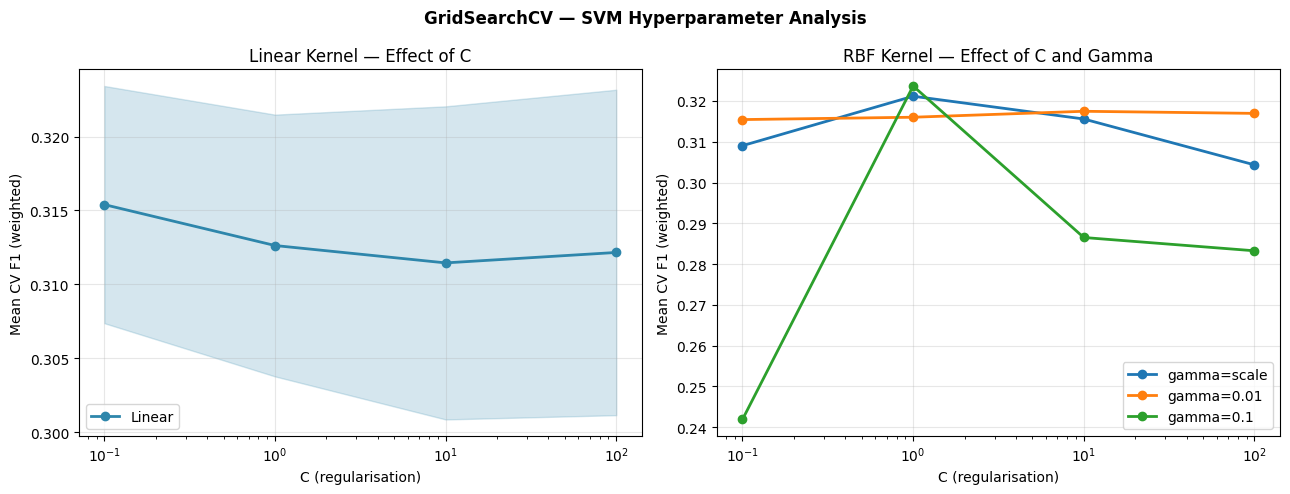

In [7]:
 # ── GridSearch results analysis ──────────────────────────────────
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False)

print("Top 10 parameter combinations:")
cols = ['param_kernel','param_C','param_gamma',
        'mean_test_score','std_test_score']
print(cv_results[cols].head(10).to_string(index=False))

# ── C vs F1 score — Linear vs RBF ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Linear kernel — C effect
linear_res = cv_results[cv_results['param_kernel'] == 'linear'].sort_values('param_C')
axes[0].plot(
    linear_res['param_C'].astype(float),
    linear_res['mean_test_score'],
    marker='o', color='#2E86AB', lw=2, label='Linear'
)
axes[0].fill_between(
    linear_res['param_C'].astype(float),
    linear_res['mean_test_score'] - linear_res['std_test_score'],
    linear_res['mean_test_score'] + linear_res['std_test_score'],
    alpha=0.2, color='#2E86AB'
)
axes[0].set_xscale('log')
axes[0].set_xlabel('C (regularisation)')
axes[0].set_ylabel('Mean CV F1 (weighted)')
axes[0].set_title('Linear Kernel — Effect of C')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# RBF kernel — C vs gamma
rbf_res = cv_results[cv_results['param_kernel'] == 'rbf']
for gamma_val in ['scale', 0.01, 0.1]:
    subset = rbf_res[
        rbf_res['param_gamma'].astype(str) == str(gamma_val)
    ].sort_values('param_C')
    if len(subset) > 0:
        axes[1].plot(
            subset['param_C'].astype(float),
            subset['mean_test_score'],
            marker='o', lw=2, label=f'gamma={gamma_val}'
        )
axes[1].set_xscale('log')
axes[1].set_xlabel('C (regularisation)')
axes[1].set_ylabel('Mean CV F1 (weighted)')
axes[1].set_title('RBF Kernel — Effect of C and Gamma')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.suptitle('GridSearchCV — SVM Hyperparameter Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_gridsearch_cv.png', dpi=150)
plt.show()

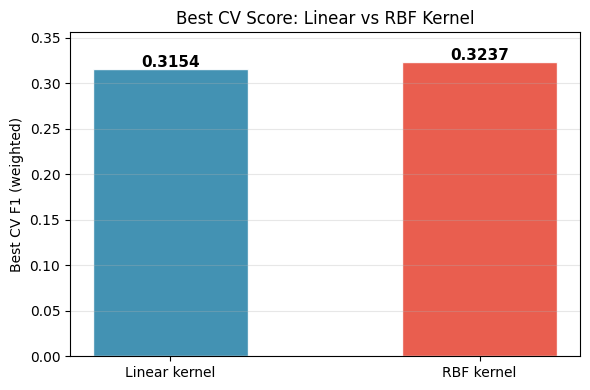

Best kernel on CV data: RBF
  Linear best CV F1: 0.3154
  RBF    best CV F1: 0.3237


In [8]:
# ── Linear vs RBF best score comparison ─────────────────────────
best_linear = cv_results[cv_results['param_kernel']=='linear']['mean_test_score'].max()
best_rbf    = cv_results[cv_results['param_kernel']=='rbf']['mean_test_score'].max()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Linear kernel', 'RBF kernel'],
              [best_linear, best_rbf],
              color=['#2E86AB','#E74C3C'], width=0.5,
              edgecolor='white', alpha=0.9)
for bar, val in zip(bars, [best_linear, best_rbf]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Best CV F1 (weighted)')
ax.set_title('Best CV Score: Linear vs RBF Kernel')
ax.set_ylim(0, max(best_linear, best_rbf) * 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('svm_kernel_comparison_cv.png', dpi=150)
plt.show()

winner = 'RBF' if best_rbf > best_linear else 'Linear'
print(f"Best kernel on CV data: {winner}")
print(f"  Linear best CV F1: {best_linear:.4f}")
print(f"  RBF    best CV F1: {best_rbf:.4f}")

---
## Section 3 — Final Model Training & Evaluation

In [9]:
# Refit final SVM with probability=True using best hyperparameters
best_params = grid_search.best_params_.copy()
best_params['probability'] = True

best_svm = SVC(**best_params)
best_svm.fit(X_train_scaled, y_train)

SVC(C=1, class_weight='balanced', gamma=0.1, probability=True)

In [10]:
y_prob = best_svm.predict_proba(X_test_scaled)

In [12]:
best_svm = grid_search.best_estimator_

y_pred = best_svm.predict(X_test_scaled)

# FIX: use decision_function
y_scores = best_svm.decision_function(X_test_scaled)

# FIX: proper classes
import numpy as np
classes = np.unique(y_train)

from sklearn.preprocessing import label_binarize
y_bin = label_binarize(y_test, classes=classes)

from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_bin, y_scores,
                        multi_class='ovr', average='weighted')

print("=" * 55)
print("SVM — TEST SET RESULTS")
print("=" * 55)
print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")

print("\nBest parameters:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

SVM — TEST SET RESULTS
  Accuracy:  0.5451
  Precision: 0.6202
  Recall:    0.5451
  F1-score:  0.5710
  ROC-AUC:   0.6679

Best parameters:
  C: 1
  class_weight: balanced
  gamma: 0.1
  kernel: rbf


In [13]:
# ── Classification report ────────────────────────────────────────
print("Classification Report (per-class breakdown):")
print(classification_report(
    y_test, y_pred,
    target_names=CLASS_NAMES,
    zero_division=0
))

Classification Report (per-class breakdown):
              precision    recall  f1-score   support

        None       0.79      0.63      0.70      1162
        Mild       0.26      0.46      0.33       316
    Moderate       0.26      0.21      0.23       189
      Severe       0.03      0.06      0.04        17

    accuracy                           0.55      1684
   macro avg       0.33      0.34      0.32      1684
weighted avg       0.62      0.55      0.57      1684



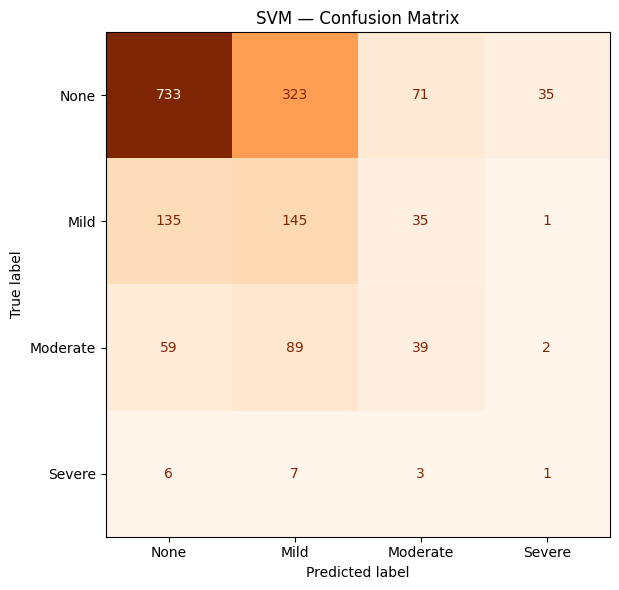

In [14]:
# ── Confusion matrix ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
ConfusionMatrixDisplay(
    cm, display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title('SVM — Confusion Matrix')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()

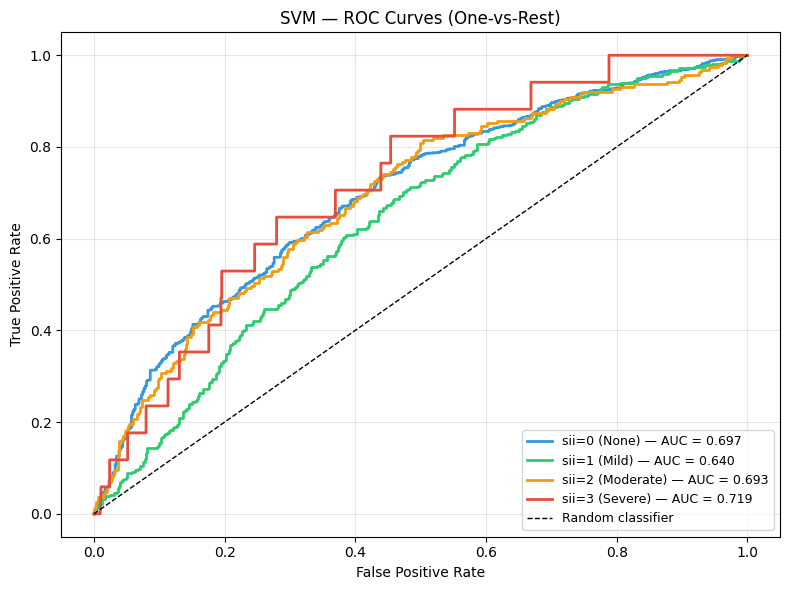

In [15]:
# ── ROC Curves — one per class ───────────────────────────────────
colors_roc = ['#3498DB','#2ECC71','#F39C12','#E74C3C']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, color, name) in enumerate(zip(CLASSES, colors_roc, CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc_cls = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'sii={cls} ({name}) — AUC = {roc_auc_cls:.3f}')

ax.plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('SVM — ROC Curves (One-vs-Rest)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svm_roc_curves.png', dpi=150)
plt.show()

---
## Section 4 — Kernel Analysis
Compare Linear vs RBF on the test set to understand what the kernel choice means for your data.

Linear vs RBF — Test Set Metrics:
           Linear     RBF
Accuracy   0.5113  0.5451
Precision  0.6262  0.6202
Recall     0.5113  0.5451
F1-score   0.5606  0.5710


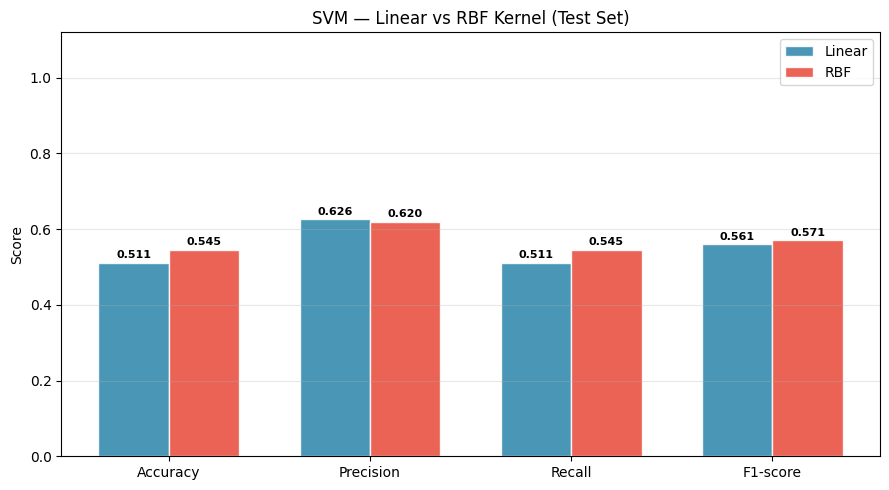

In [16]:
# ── Train best Linear and best RBF separately for comparison ─────
# Best linear params
best_linear_row = cv_results[cv_results['param_kernel']=='linear'].iloc[0]
svm_linear = SVC(
    kernel='linear',
    C=float(best_linear_row['param_C']),
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_linear.fit(X_train_scaled, y_train)
pred_linear = svm_linear.predict(X_test_scaled)

# Best RBF params
best_rbf_row = cv_results[cv_results['param_kernel']=='rbf'].iloc[0]
svm_rbf = SVC(
    kernel='rbf',
    C=float(best_rbf_row['param_C']),
    gamma=best_rbf_row['param_gamma'],
    class_weight='balanced',
    probability=True,
    random_state=42
)
svm_rbf.fit(X_train_scaled, y_train)
pred_rbf = svm_rbf.predict(X_test_scaled)

# ── Side-by-side metrics ─────────────────────────────────────────
metrics_comparison = pd.DataFrame({
    'Linear': {
        'Accuracy':  accuracy_score(y_test, pred_linear),
        'Precision': precision_score(y_test, pred_linear, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, pred_linear, average='weighted', zero_division=0),
        'F1-score':  f1_score(y_test, pred_linear, average='weighted', zero_division=0),
    },
    'RBF': {
        'Accuracy':  accuracy_score(y_test, pred_rbf),
        'Precision': precision_score(y_test, pred_rbf, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, pred_rbf, average='weighted', zero_division=0),
        'F1-score':  f1_score(y_test, pred_rbf, average='weighted', zero_division=0),
    }
}).round(4)

print("Linear vs RBF — Test Set Metrics:")
print(metrics_comparison.to_string())

# ── Bar chart comparison ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics_comparison.index))
width = 0.35
ax.bar(x - width/2, metrics_comparison['Linear'],
       width, label='Linear', color='#2E86AB', alpha=0.87, edgecolor='white')
ax.bar(x + width/2, metrics_comparison['RBF'],
       width, label='RBF',    color='#E74C3C', alpha=0.87, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(metrics_comparison.index)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('SVM — Linear vs RBF Kernel (Test Set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (vl, vr) in enumerate(zip(metrics_comparison['Linear'], metrics_comparison['RBF'])):
    ax.text(i - width/2, vl + 0.012, f'{vl:.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.text(i + width/2, vr + 0.012, f'{vr:.3f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_linear_vs_rbf.png', dpi=150)
plt.show()

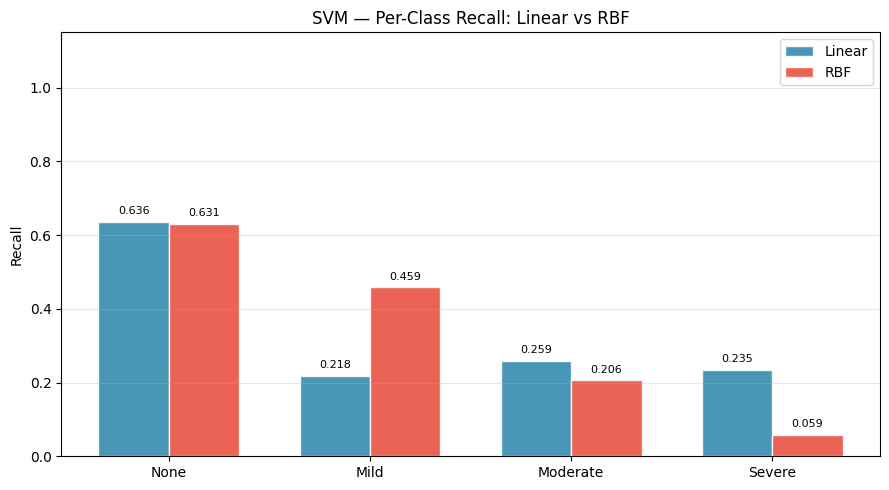

Per-class recall — Linear vs RBF:
  None: Linear=0.6360 | RBF=0.6308
  Mild: Linear=0.2184 | RBF=0.4589
  Moderate: Linear=0.2593 | RBF=0.2063
  Severe: Linear=0.2353 | RBF=0.0588


In [17]:

# ── Per-class recall: Linear vs RBF ─────────────────────────────
from sklearn.metrics import recall_score as rec

recall_linear = rec(y_test, pred_linear, labels=CLASSES, average=None, zero_division=0)
recall_rbf    = rec(y_test, pred_rbf,    labels=CLASSES, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(4)
width = 0.35
ax.bar(x - width/2, recall_linear, width,
       label='Linear', color='#2E86AB', alpha=0.87, edgecolor='white')
ax.bar(x + width/2, recall_rbf,    width,
       label='RBF',    color='#E74C3C', alpha=0.87, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel('Recall')
ax.set_ylim(0, 1.15)
ax.set_title('SVM — Per-Class Recall: Linear vs RBF')
ax.legend()
ax.grid(axis='y', alpha=0.3)
for i, (vl, vr) in enumerate(zip(recall_linear, recall_rbf)):
    ax.text(i - width/2, vl + 0.02, f'{vl:.3f}', ha='center', fontsize=8)
    ax.text(i + width/2, vr + 0.02, f'{vr:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('svm_perclass_recall_kernels.png', dpi=150)
plt.show()

print("Per-class recall — Linear vs RBF:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: Linear={recall_linear[i]:.4f} | RBF={recall_rbf[i]:.4f}")

---
## Section 5 — Feature Importance (Linear SVM only)
Linear SVM has explicit feature weights per class — interpretable like LR coefficients.  
RBF SVM maps features into a non-linear space — no direct feature weights available.

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,...,FGC_Flexibility_Avg,FGC_Grip_Avg,PAQ_Total,SDS_measured,BIA_measured,FGC_Muscular_Endurance,Social_Digital_Displacement,Lifestyle_Risk_Score,Metabolic_Alarms_Count,ScreenTime_Age_Ratio
sii=0 vs sii=1,-0.145764,0.093244,-0.037835,0.235605,-0.285084,-0.190722,0.031423,-0.067439,-0.091365,0.100292,...,0.028031,0.182442,-0.025408,-0.334225,0.0,-0.293139,-0.503073,0.245505,-0.182098,-0.123486
sii=0 vs sii=2,-0.059795,0.148970,0.007470,0.117327,-0.176533,-0.044007,0.027838,-0.029609,-0.066334,0.026584,...,0.028737,-0.030270,-0.133890,-0.155342,0.0,-0.132666,0.007613,-0.359008,-0.110880,0.141055
sii=0 vs sii=3,-0.297986,0.287674,0.160936,-0.371581,-0.244446,-0.205172,0.261967,0.041192,0.287645,-0.043322,...,-0.111402,-0.067789,0.173554,-0.062786,0.0,-0.198915,0.217985,-0.003689,0.251229,0.040289
sii=1 vs sii=2,-0.121902,0.210265,0.042891,-0.045904,0.041019,0.108453,-0.048562,0.054445,0.038229,-0.062512,...,-0.019287,-0.073914,-0.091887,0.118179,0.0,0.007337,0.144042,-0.504620,-0.000658,0.009599
sii=1 vs sii=3,-0.405269,0.349451,0.223539,-0.521899,0.076641,-0.149807,0.181884,0.183549,0.353558,-0.246809,...,-0.105751,-0.141322,0.148178,0.179142,0.0,-0.105958,-0.131756,-0.344886,0.560639,-0.083106
sii=2 vs sii=3,-0.149677,0.239874,0.320081,-0.328860,0.163246,-0.320358,0.207107,0.229649,0.457960,-0.155347,...,-0.046860,-0.024881,0.393099,0.204624,0.0,-0.120006,-0.383495,0.236708,0.344337,0.244831


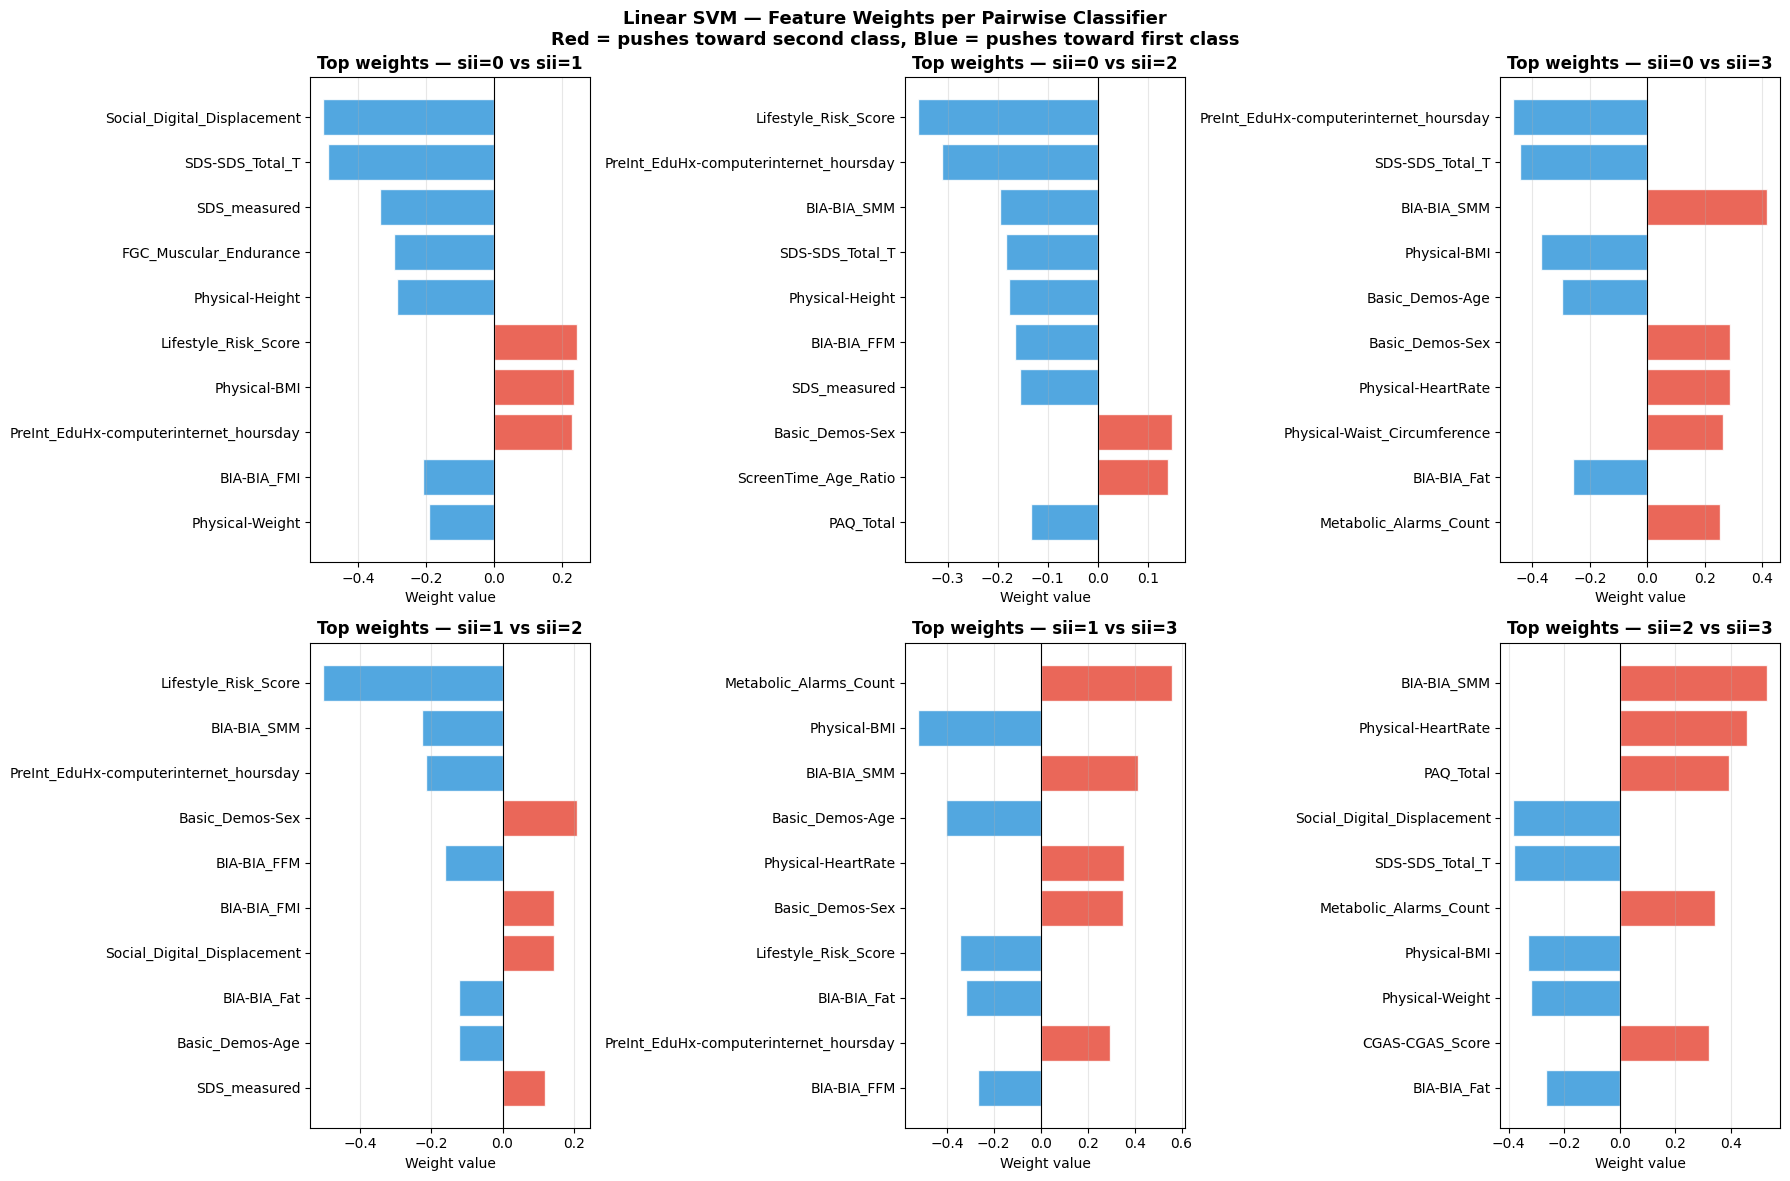

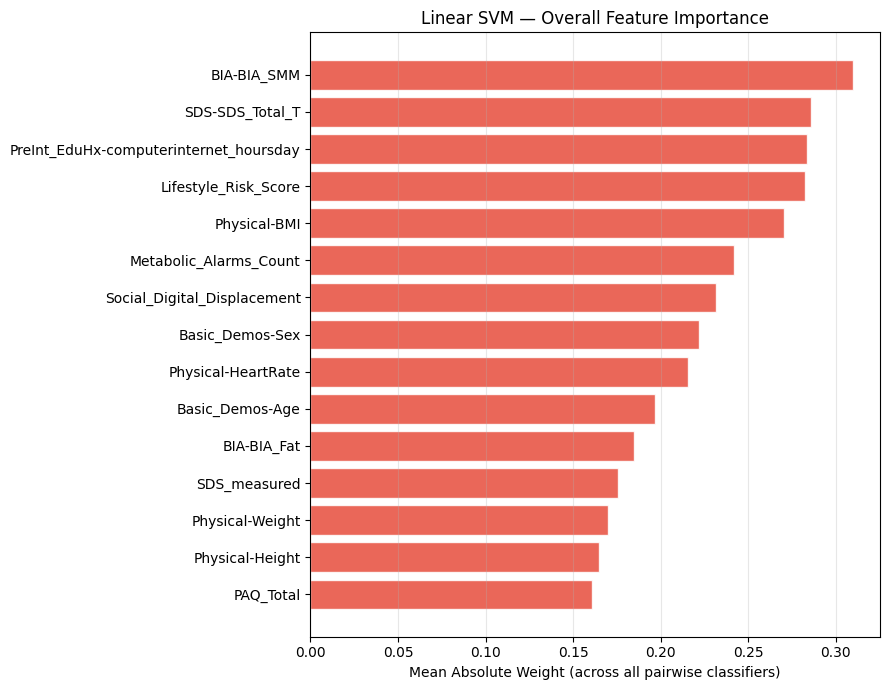

Top 10 most influential features (Linear SVM):
BIA-BIA_SMM                               0.3097
SDS-SDS_Total_T                           0.2859
PreInt_EduHx-computerinternet_hoursday    0.2837
Lifestyle_Risk_Score                      0.2824
Physical-BMI                              0.2702
Metabolic_Alarms_Count                    0.2416
Social_Digital_Displacement               0.2313
Basic_Demos-Sex                           0.2216
Physical-HeartRate                        0.2158
Basic_Demos-Age                           0.1967


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

if svm_linear.kernel == 'linear':

    # Pairwise classifier labels for multiclass SVM (OvO)
    pair_labels = [f'sii={a} vs sii={b}' for a, b in combinations(CLASSES, 2)]

    coef_df = pd.DataFrame(
        svm_linear.coef_,
        index=pair_labels,
        columns=feature_cols
    )

    display(coef_df)

    # Plot top features for each pairwise classifier
    n_pairs = len(coef_df.index)
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for ax, pair in zip(axes, coef_df.index):
        vals = coef_df.loc[pair]
        top = vals.abs().nlargest(10).index
        top_vals = vals.loc[top]
        colors_bar = ['#E74C3C' if v > 0 else '#3498DB' for v in top_vals]

        ax.barh(top, top_vals, color=colors_bar, alpha=0.85, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_title(f'Top weights — {pair}', fontweight='bold')
        ax.set_xlabel('Weight value')
        ax.invert_yaxis()
        ax.grid(axis='x', alpha=0.3)

    plt.suptitle(
        'Linear SVM — Feature Weights per Pairwise Classifier\n'
        'Red = pushes toward second class, Blue = pushes toward first class',
        fontsize=13,
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('svm_linear_weights.png', dpi=150)
    plt.show()

    # Overall feature importance across all pairwise classifiers
    mean_abs = coef_df.abs().mean(axis=0).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.barh(mean_abs.index[:15], mean_abs.values[:15],
            color='#E74C3C', alpha=0.85, edgecolor='white')
    ax.set_xlabel('Mean Absolute Weight (across all pairwise classifiers)')
    ax.set_title('Linear SVM — Overall Feature Importance')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('svm_feature_importance.png', dpi=150)
    plt.show()

    print("Top 10 most influential features (Linear SVM):")
    print(mean_abs.head(10).round(4).to_string())

else:
    print("Best model uses RBF kernel — feature weights not directly available.")
    print("Use SHAP or LIME for feature importance on RBF kernel.")

---
## Section 6 — Per-Class Recall Heatmap

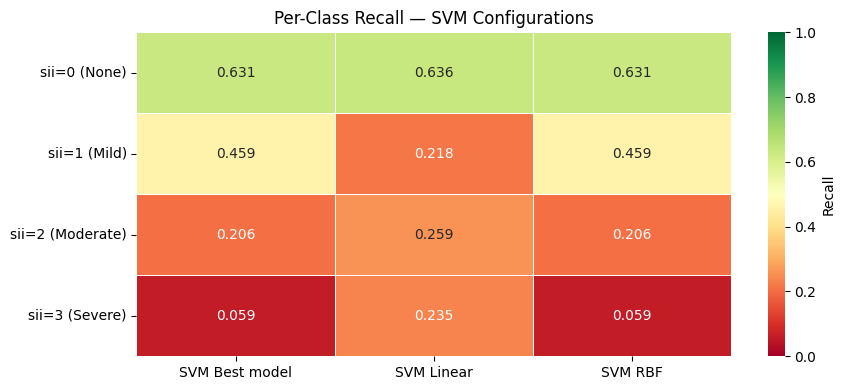

Focus: sii=3 (Severe) row — rarest and most important class.


In [20]:
# ── Recall heatmap ───────────────────────────────────────────────
configs = [
    ('SVM Best model', y_pred),
    ('SVM Linear',     pred_linear),
    ('SVM RBF',        pred_rbf),
]

per_class = {}
for label, y_p in configs:
    per_class[label] = rec(
        y_test, y_p, labels=CLASSES, average=None, zero_division=0
    )

recall_heatmap = pd.DataFrame(
    per_class,
    index=['sii=0 (None)','sii=1 (Mild)',
           'sii=2 (Moderate)','sii=3 (Severe)']
)

plt.figure(figsize=(9, 4))
sns.heatmap(recall_heatmap, annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Recall'})
plt.title('Per-Class Recall — SVM Configurations')
plt.tight_layout()
plt.savefig('svm_recall_heatmap.png', dpi=150)
plt.show()
print("Focus: sii=3 (Severe) row — rarest and most important class.")

---
## Section 7 — Summary & Conclusions

In [22]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Final summary
y_pred_final = best_svm.predict(X_test_scaled)
y_scores_final = best_svm.decision_function(X_test_scaled)

classes = np.unique(y_train)
y_bin_final = label_binarize(y_test, classes=classes)

final_roc = roc_auc_score(
    y_bin_final,
    y_scores_final,
    multi_class='ovr',
    average='weighted'
)

print("=" * 60)
print("FINAL SVM SUMMARY")
print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred_final, average='weighted', zero_division=0):.4f}")
print(f"ROC-AUC  : {final_roc:.4f}")

FINAL SVM SUMMARY
Accuracy : 0.5451
Precision: 0.6202
Recall   : 0.5451
F1-score : 0.5710
ROC-AUC  : 0.6679
